In [1]:
import pandas as pd
import os
import json
import numpy as np
# create df of results for the baseline model trained on the 
# full data with a corresponding seed
def construct_df_full_data (json_path,  seed, rename_columns = None):
    folder = os.path.join(json_path, "full_data")
    file_scores = [file for file in os.listdir(folder) if f"best-seed{seed}" in file][0]

    json_file = open(os.path.join(folder, file_scores))
    json1_str = json_file.read()
    json1_data = json.loads(json1_str)
    clsuter_keys = set(json1_data.keys())
    #print(len(clsuter_keys))
    df  = pd.DataFrame(json1_data).T
    if rename_columns is not None:
       mapping = { col: f"{col}_{rename_columns}_{seed}" for col in df.columns}
       df = df.rename(columns=mapping)
    return df

# cerate df of results for the clustering configutation for one cluster
def construct_df_clsuter_data(json_path, seed, cluster_config, cluster_number,rename_columns= None):
    folder = os.path.join(json_path, cluster_config, f"{cluster_number}")
    #print(folder)
    file_scores = [file for file in os.listdir(folder) if  file.startswith(f"best-seed{seed}")][0]   # f"best_checkpoint-seed{seed}" in file best_checkpoint-seed

    json_file = open(os.path.join(folder, file_scores))
    json1_str = json_file.read()
    json1_data = json.loads(json1_str)
    clsuter_keys = set(json1_data.keys())
    #print(len(clsuter_keys))
    df  = pd.DataFrame(json1_data).T
    if rename_columns is not None:
       mapping = { col: f"{col}_{rename_columns}_{seed}" for col in df.columns}
       df = df.rename(columns=mapping)
    return df

# join results for all clusters in the given clustering configuration and join then in final df
def construct_total_df (json_path, seed, cluster_config, cluster_numbers, rename_columns= None):
    df_list = []
    for cluster_number in cluster_numbers:
        df_cluster = construct_df_clsuter_data(json_path, seed, cluster_config, cluster_number, rename_columns= rename_columns)
        df_list.append (df_cluster)
    df_total = pd.concat(df_list, axis=0)
    df = df_total.groupby(df_total.index).mean()
    # sanity check on number of validation files (should be 556)
    assert len(df) == 556
    #print(f"Final size of df is {len(df)}")
    return df

# get dict of differences between the baseline model and configuration model
# returns dict with keys that are beat tracking metrics
def get_performance_differences(df_total, df_full):
    means_total = (df_total.mean()* 100).to_dict()
    means_full =(df_full.mean()*  100).to_dict()
    diff_dict = {list(means_total.keys())[i]: means_total[list(means_total.keys())[i]] - means_full[list(means_full.keys())[i]] for i in range(len(means_full))}
    return diff_dict

# utility function to rename dictionary keys
def rename_keys_dict(d):
    dict_new = {}
    for key in d.keys():
        new_key = "_".join(key.split("_")[:-1])
        dict_new [new_key] = d[key]
    return dict_new

# get differences in performance for a particular configuration for all seeds
def get_total_results_old (seeds, json_val_path,layer, clusters):
    df_list = []
    cluster_numbers = np.arange(clusters) +1
    cluster_config = f"clusters{clusters}_layer{layer}"
    for seed in seeds:
        df_total = construct_total_df (json_val_path, seed=seed, cluster_config=cluster_config, cluster_numbers=cluster_numbers)
        df_full = construct_df_full_data (json_val_path, seed=seed, rename_columns="baseline")
        diff_dict = get_performance_differences (df_total, df_full)
        diff_dict_renamed = rename_keys_dict(diff_dict)
        #print(diff_dict_renamed)
        df = pd.DataFrame.from_dict(diff_dict_renamed, orient="index", columns=[f"Value_{seed}"])
        #df.index.name = "Metric"
        df_list.append(df)
    df_result =  pd.concat(df_list, axis=1)
    return df_result

In [2]:
def get_total_results(seeds, json_val_path,layer = None, clusters = None, full = False, rename_columns = None):
    df_list = []
    for seed in seeds:
        if full:
            df_total = construct_df_full_data (json_val_path, seed=seed, rename_columns=rename_columns)
        else:
            cluster_numbers = np.arange(clusters) +1
            cluster_config = f"clusters{clusters}_layer{layer}"
            df_total = construct_total_df (json_val_path, seed=seed, cluster_config=cluster_config, cluster_numbers=cluster_numbers, rename_columns=rename_columns)
        means_total = (df_total.mean()* 100).to_dict()
        means_total_renamed =means_total.copy()# rename_keys_dict(means_total)
        #print(diff_dict_renamed)
        df = pd.DataFrame.from_dict(means_total_renamed  , orient="index", columns=[f"configuration_{seed}"])
        #df.index.name = "Metric"
        df_list.append(df)
    df_result =  pd.concat(df_list, axis=1)
    df_seeds_mean = df_result.mean(axis = 1)
    df_seeds_std = df_result.std(axis = 1)
    df_final = df_seeds_mean.round(3).astype(str) + " ± " + df_seeds_std.round(3).astype(str)
    return df_seeds_mean, df_seeds_std, df_final

In [9]:
seeds = [0,1,2]
df_seeds_mean, df_seeds_std, df_final_baseline = get_total_results(seeds = seeds, json_val_path = "json_val_scores", full = True ) #rename_columns="baseline"
df_seeds_mean, df_seeds_std, df_final_clusters2_layer6 = get_total_results(seeds = seeds, json_val_path = "json_val_scores", layer = 6, clusters = 2)
df_seeds_mean, df_seeds_std, df_final_clusters4_layer12 = get_total_results(seeds = seeds, json_val_path = "json_val_scores", layer = 12, clusters = 4)
df_seeds_mean, df_seeds_std, df_final_clusters3_layer113= get_total_results(seeds =seeds , json_val_path = "json_val_scores", layer = 113, clusters = 3)
configs = {
    "clusters2_layer6": df_final_clusters2_layer6,
    "clusters4_layer12": df_final_clusters4_layer12,
    
    "clusters3_raw" : df_final_clusters3_layer113,
    "baseline": df_final_baseline
}
final_df = pd.DataFrame(configs).T 
final_df

,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat
clusters2_layer6,92.842 ± 0.32,84.851 ± 0.294,85.247 ± 0.356,88.88 ± 0.519,85.267 ± 0.395,79.101 ± 0.451,72.801 ± 0.299,80.468 ± 0.827
clusters4_layer12,92.793 ± 0.267,84.882 ± 0.276,85.208 ± 0.342,88.857 ± 0.584,85.279 ± 0.37,79.087 ± 0.352,72.797 ± 0.044,80.254 ± 0.101
clusters3_raw,92.737 ± 0.266,84.77 ± 0.244,85.092 ± 0.441,88.724 ± 0.293,85.107 ± 0.404,78.946 ± 0.372,72.604 ± 0.097,80.091 ± 0.331
baseline,92.655 ± 0.432,84.806 ± 0.357,84.891 ± 0.828,88.703 ± 0.448,85.143 ± 0.41,79.019 ± 0.405,72.473 ± 0.427,79.997 ± 0.715


In [10]:
def extract_mean(series):
    return series.str.split("±").str[0].astype(float)
df_means_only = final_df.apply(extract_mean, axis=1)
diff_vs_baseline = df_means_only.subtract(df_means_only.loc["baseline"])
diff_vs_baseline = diff_vs_baseline.drop(index="baseline")
diff_vs_baseline

,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat
clusters2_layer6,0.187,0.045,0.356,0.177,0.124,0.082,0.328,0.471
clusters4_layer12,0.138,0.076,0.317,0.154,0.136,0.068,0.324,0.257
clusters3_raw,0.082,-0.036,0.201,0.021,-0.036,-0.073,0.131,0.094


In [12]:
df_seeds_mean, df_seeds_std, df_final = get_total_results(seeds = [0,1, 2], json_val_path = "json_val_scores", full = True ) #rename_columns="baseline"
df_final

F-measure_beat        92.655 ± 0.432
Cemgil_beat           84.806 ± 0.357
CMLt_beat             84.891 ± 0.828
AMLt_beat             88.703 ± 0.448
F-measure_downbeat     85.143 ± 0.41
Cemgil_downbeat       79.019 ± 0.405
CMLt_downbeat         72.473 ± 0.427
AMLt_downbeat         79.997 ± 0.715
dtype: object

In [78]:
df_seeds_mean, df_seeds_std, df_final = get_total_results(seeds = [0,1, 2], json_val_path = "json_val_scores", layer = 6, clusters = 2)
df_final

F-measure_beat         92.842 ± 0.32
Cemgil_beat           84.851 ± 0.294
CMLt_beat             85.247 ± 0.356
AMLt_beat              88.88 ± 0.519
F-measure_downbeat    85.267 ± 0.395
Cemgil_downbeat       79.101 ± 0.451
CMLt_downbeat         72.801 ± 0.299
AMLt_downbeat         80.468 ± 0.827
dtype: object

In [79]:
df_seeds_mean, df_seeds_std, df_final= get_total_results(seeds = [0,1, 2], json_val_path = "json_val_scores", layer = 12, clusters = 4)
df_final

F-measure_beat        92.793 ± 0.267
Cemgil_beat           84.882 ± 0.276
CMLt_beat             85.208 ± 0.342
AMLt_beat             88.857 ± 0.584
F-measure_downbeat     85.279 ± 0.37
Cemgil_downbeat       79.087 ± 0.352
CMLt_downbeat         72.797 ± 0.044
AMLt_downbeat         80.254 ± 0.101
dtype: object

In [80]:
df_seeds_mean, df_seeds_std, df_final= get_total_results(seeds = [0,1, 2], json_val_path = "json_val_scores", layer = 113, clusters = 3)
df_final

F-measure_beat        92.737 ± 0.266
Cemgil_beat            84.77 ± 0.244
CMLt_beat             85.092 ± 0.441
AMLt_beat             88.724 ± 0.293
F-measure_downbeat    85.107 ± 0.404
Cemgil_downbeat       78.946 ± 0.372
CMLt_downbeat         72.604 ± 0.097
AMLt_downbeat         80.091 ± 0.331
dtype: object

In [28]:
df2 = get_total_results(seeds = [0,1, 2], json_val_path = "json_val_scores", layer = 6, clusters = 2)
df2

,Value_0,Value_1,Value_2
F-measure_beat_clusters2_layer6,0.194616,0.070607,0.294833
Cemgil_beat_clusters2_layer6,0.211529,-0.197048,0.118469
CMLt_beat_clusters2_layer6,0.604886,-0.204598,0.667013
AMLt_beat_clusters2_layer6,0.648409,-0.203882,0.084351
F-measure_downbeat_clusters2_layer6,0.323536,-0.018012,0.065326
Cemgil_downbeat_clusters2_layer6,0.355536,-0.125521,0.015311
CMLt_downbeat_clusters2_layer6,0.673556,0.173159,0.138442
AMLt_downbeat_clusters2_layer6,1.391031,0.252737,-0.229233


In [16]:
# using df with per track cluster assignments, return only tracks
# that belong to the chosen cluster
def get_cluster_files (cluster, df_path):
    df_assignments = pd.read_csv(df_path)
    df_assignments_filtered =  df_assignments[ df_assignments["label"].str.contains(str(cluster))]
    cluster_files = df_assignments_filtered ["file"].values
    cluster_genres = [genres for genres in df_assignments_filtered ["label"].unique() if "(" in genres ][0]
    return cluster_files, cluster_genres

#compute scores only for tracks from a given cluster
# when per_cluster set to False, we compute scores for all tracks
def get_restults_per_cluster (json_path,  cluster, seeds, df_path, full= False, layer = None, n_clusters = None, per_cluster = True ):
    if full:
        folder = os.path.join(json_path, "full_data")
    else:
        cluster_config = f"clusters{n_clusters}_layer{layer}"
        folder =  os.path.join(json_path, cluster_config, f"{cluster}")
    cluster_files, cluster_genres = get_cluster_files (cluster= cluster, df_path = df_path)
    print(f"genres are {cluster_genres}")
    cluster_files = [file.replace("___", "/") for file in cluster_files]
    #print(cluster_files)
    scores = []
    for seed in seeds:
        file_scores = [file for file in os.listdir(folder) if  file.startswith(f"best-seed{seed}")][0]
        json_file = open(os.path.join(folder, file_scores))
        json1_str = json_file.read()
        json1_data = json.loads(json1_str)
        json_data = {key[:-10]: value for key, value in json1_data.items()}
        df  = pd.DataFrame(json_data).T
        if full and per_cluster:
            ind = set(df.index)
            cl = set(cluster_files)
            val_files_cluster = ind & cl
            df_val_cluster = df.loc[list(val_files_cluster)]
        else:
            df_val_cluster = df.copy()
        scores_mean = (df_val_cluster.mean()*100).to_dict()
        scores.append(scores_mean)
    print(len(df_val_cluster))
    return scores

In [24]:
df2 = get_total_results(seeds = [0,1, 2], json_val_path = "json_val_scores", layer = 6, clusters = 2)
clusters2_layer6 = df2.mean(axis = 1).to_dict()
clusters2_layer6 = {key.split("_clusters")[0]: value for key, value in clusters2_layer6.items()}
clusters2_layer6 
#df2
df_res2 = pd.DataFrame.from_dict(clusters2_layer6 , orient="index", columns=[f"Value_{1}"])
df_res2

,Value_1
F-measure_beat,0.186685
Cemgil_beat,0.044317
CMLt_beat,0.355767
AMLt_beat,0.176293
F-measure_downbeat,0.123617
Cemgil_downbeat,0.081775
CMLt_downbeat,0.328386
AMLt_downbeat,0.471512


In [25]:
df4 = get_total_results(seeds = [0,1, 2], json_val_path = "json_val_scores", layer = 12, clusters = 4)
df4.mean(axis = 1)


F-measure_beat_clusters4_layer12        0.138007
Cemgil_beat_clusters4_layer12           0.076018
CMLt_beat_clusters4_layer12             0.316776
AMLt_beat_clusters4_layer12             0.153491
F-measure_downbeat_clusters4_layer12    0.135693
Cemgil_downbeat_clusters4_layer12       0.068235
CMLt_downbeat_clusters4_layer12         0.323590
AMLt_downbeat_clusters4_layer12         0.257154
dtype: float64

In [83]:
df3 = get_total_results(seeds = [0,1, 2], json_val_path = "json_val_scores", layer = 113, clusters = 3)
df3.mean(axis = 1)


F-measure   -0.036221
Cemgil      -0.072493
CMLt         0.130712
AMLt         0.093984
dtype: float64

In [8]:
df2 = get_total_results(seeds = [0,1,2], json_val_path = "json_val_scores", layer = 6, clusters = 2)
df2.mean(axis = 1)


F-measure    0.123617
Cemgil       0.081775
CMLt         0.328386
AMLt         0.471512
dtype: float64

In [27]:

json_path = "json_val_scores"
scores = get_restults_per_cluster (json_path,  cluster = 4, seeds = [0,1,2], df_path= "data_cluster_assignments/df_cmeans_12_4clusters_new.csv", full = True, per_cluster=False )
df = pd.DataFrame(scores)

summary = pd.DataFrame({
    "mean": df.mean(),
    "std": df.std()
})
summary

genres are 4 (Classical)
556


,mean,std
F-measure_beat,92.655061,0.431561
Cemgil_beat,84.806237,0.357194
CMLt_beat,84.891240,0.828499
AMLt_beat,88.703282,0.447577
F-measure_downbeat,85.142924,0.409585
Cemgil_downbeat,79.018963,0.405184
CMLt_downbeat,72.473105,0.427301
AMLt_downbeat,79.996665,0.715134


In [11]:
json_path = "json_val_scores"
layer = 12
cluster_numbers = [1,2,3,4]
df_list = []
seed = 0
cluster_config = "clusters4_layer12"
for cluster_number in cluster_numbers:
    df_cluster = construct_df_clsuter_data(json_path, seed, cluster_config, cluster_number, rename_columns= cluster_config)
    df_list.append (df_cluster)
df_total = pd.concat(df_list, axis=0)
df = df_total.groupby(df_total.index).mean()
# sanity check on number of validation files (should be 556)
print(f"Final size of df is {len(df)}")
df.head()

json_val_scores/clusters4_layer12/1
220
json_val_scores/clusters4_layer12/2
123
json_val_scores/clusters4_layer12/3
153
json_val_scores/clusters4_layer12/4
106
Final size of df is 556


,F-measure_beat_clusters4_layer12_0,Cemgil_beat_clusters4_layer12_0,CMLt_beat_clusters4_layer12_0,AMLt_beat_clusters4_layer12_0,F-measure_downbeat_clusters4_layer12_0,Cemgil_downbeat_clusters4_layer12_0,CMLt_downbeat_clusters4_layer12_0,AMLt_downbeat_clusters4_layer12_0
asap/Bach_Fugue_bwv_873_Lisiecki13M/track.npy,0.979206,0.932761,0.929104,0.929104,0.653061,0.668686,0.131783,0.458647
asap/Bach_Fugue_bwv_874_BianF01/track.npy,0.106383,0.086865,0.000000,0.580311,0.070000,0.047430,0.000000,0.000000
asap/Bach_Fugue_bwv_874_Kurz01M/track.npy,0.664384,0.751126,0.000000,0.979487,0.574850,0.647456,0.000000,0.621849
asap/Bach_Fugue_bwv_874_WongWY01M/track.npy,0.664384,0.764902,0.000000,0.974359,0.540230,0.618602,0.000000,0.515873
asap/Bach_Fugue_bwv_875_Ahfat01M/track.npy,0.733333,0.706838,0.401460,0.401460,0.380952,0.402207,0.000000,0.240506


In [89]:
def get_cluster_files (cluster, df_path):
    df_assignments = pd.read_csv(df_path)
    df_assignments_filtered =  df_assignments[ df_assignments["label"].str.contains(str(cluster))]
    cluster_files = df_assignments_filtered ["file"].values
    cluster_genres = [genres for genres in df_assignments_filtered ["label"].unique() if "(" in genres ][0]
    return cluster_files, cluster_genres

In [ ]:
cluster_files, cluster_genres = get_cluster_files (cluster= 1, config="clusters4_layer12" )
len(cluster_files)
cluster_files = [file.replace("___", "/") for file in cluster_files]
cluster_files

In [66]:
json_path = "json_val_scores"
seed = 0
folder = os.path.join(json_path, "full_data")
file_scores = [file for file in os.listdir(folder) if f"best-seed{seed}" in file][0]

json_file = open(os.path.join(folder, file_scores))
json1_str = json_file.read()
json1_data = json.loads(json1_str)
json_data = {key[:-10]: value for key, value in json1_data.items()}
clsuter_keys = set(json_data.keys())
print(len(clsuter_keys))
df  = pd.DataFrame(json_data).T
ind = set(df.index)
cl = set(cluster_files)
val_files_cluster = ind & cl
df_val_cluster = df.loc[list(val_files_cluster)]
df_val_cluster.head()

556


,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat
ballroom/ballroom_Albums-Mambo_Kings-12,1.000000,0.974577,1.000000,1.000000,1.000000,0.980364,1.000000,1.000000
ballroom/ballroom_Albums-Latin_Jam2-06,1.000000,0.975458,1.000000,1.000000,0.866667,0.837013,0.529412,0.529412
harmonix/0129_hotinherre,0.970414,0.915193,0.960630,0.960630,0.961240,0.909571,0.969231,0.969231
candombe/csic.1995_ansina2_04,0.999404,0.949421,0.998808,0.998808,1.000000,0.956972,1.000000,1.000000
groove_midi/drummer8_session1_23_hiphop_70_beat_4-4,1.000000,0.917729,1.000000,1.000000,0.947368,0.871037,0.816667,0.816667


In [72]:
json_path = "json_val_scores"
seed = 1
folder = os.path.join(json_path, "full_data")
file_scores = [file for file in os.listdir(folder) if f"best-seed{seed}" in file][0]

json_file = open(os.path.join(folder, file_scores))
json1_str = json_file.read()
json1_data = json.loads(json1_str)
json_data = {key[:-10]: value for key, value in json1_data.items()}
clsuter_keys = set(json_data.keys())
print(len(clsuter_keys))
df  = pd.DataFrame(json_data).T
ind = set(df.index)
cl = set(cluster_files)
val_files_cluster = ind & cl
df_val_cluster1 = df.loc[list(val_files_cluster)]
(df_val_cluster1.mean()*100).to_dict()

556


{'F-measure_beat': 97.27310627981272,
 'Cemgil_beat': 89.27179435611238,
 'CMLt_beat': 94.50054523988209,
 'AMLt_beat': 96.25630182569509,
 'F-measure_downbeat': 91.60536558786113,
 'Cemgil_downbeat': 85.11098071576349,
 'CMLt_downbeat': 86.29160024151741,
 'AMLt_downbeat': 90.91530254129052}

In [115]:
def get_restults_per_cluster (json_path,  cluster, seeds, df_path, full= False,cluster_config = None, per_cluster = False ):
    if full:
        folder = os.path.join(json_path, "full_data")
    else:
        #cluster_config = f"clusters{n_clusters}_layer{layer}"
        folder =  os.path.join(json_path, cluster_config, f"{cluster}")
    cluster_files, cluster_genres = get_cluster_files (cluster= cluster, df_path = df_path)
    # if (per_cluster and  full) or (not full):
       
    cluster_files = [file.replace("___", "/") for file in cluster_files]
    #print(cluster_files)
    scores = []
    for seed in seeds:
        file_scores = [file for file in os.listdir(folder) if  file.startswith(f"best-seed{seed}")][0]
        json_file = open(os.path.join(folder, file_scores))
        json1_str = json_file.read()
        json1_data = json.loads(json1_str)
        json_data = {key[:-10]: value for key, value in json1_data.items()}
        df  = pd.DataFrame(json_data).T
        if full and per_cluster:
            ind = set(df.index)
            cl = set(cluster_files)
            val_files_cluster = ind & cl
            df_val_cluster = df.loc[list(val_files_cluster)]
        else:
            df_val_cluster = df.copy()
        scores_mean = (df_val_cluster.mean()*100).to_dict()
        scores.append(scores_mean)
    print(len(df_val_cluster))
    if not full:
        genres = cluster_genres[cluster_genres.find("(")+1:cluster_genres.find(")")]
        print(f"genres are {genres}")
        return scores, genres
    return scores

In [113]:
import matplotlib.pyplot as plt
def gete_f1_av(scores):
    df = pd.DataFrame(scores)
    summary = pd.DataFrame({
        "mean": df.mean(),
        "std": df.std()
    })
    return summary.loc["F-measure_beat", "mean"]
def bar_plot_per_cluster (df_path, json_path, clusters, seeds, cluster_config ):
    full_scores =  {}
    config_scores = {}
    for cluster in clusters:
        scores_full = get_restults_per_cluster (json_path,  cluster =cluster, seeds = seeds, df_path=df_path, full = True, per_cluster=True )
        scores_config, cluster_genres = get_restults_per_cluster (json_path,  cluster =cluster, seeds = seeds, df_path=df_path, full = False, cluster_config=cluster_config )
        full_scores[cluster] = gete_f1_av(scores_full)
        config_scores[cluster] = gete_f1_av(scores_config)
    fig, ax = plt.subplots(figsize=(10,5))
        #ax.barplot()
        
    ax.bar(clusters, list(full_scores.values()), align='center')


In [130]:
import numpy as np
import matplotlib.pyplot as plt

def bar_plot_per_cluster(df_path, json_path, clusters, seeds, cluster_config):
    full_scores = {}
    config_scores = {}
    cluster_labels = []   # for x-tick labels (genres per cluster)

    for cluster in clusters:
        scores_full = get_restults_per_cluster(
            json_path, cluster=cluster, seeds=seeds,
            df_path=df_path, full=True, per_cluster=True
        )
        scores_config, cluster_genres = get_restults_per_cluster(
            json_path, cluster=cluster, seeds=seeds,
            df_path=df_path, full=False, cluster_config=cluster_config
        )

        full_scores[cluster] = gete_f1_av(scores_full)
        config_scores[cluster] = gete_f1_av(scores_config)

        # assuming cluster_genres is a list of strings; adjust if needed
        cluster_labels.append(cluster_genres)

    # --- plotting ---
    clusters = list(clusters)
    x = np.arange(len(clusters))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 8))

    # one color per cluster
    colors = plt.cm.tab10(np.arange(len(clusters)) % 10)

    full_vals = [full_scores[c] for c in clusters]
    config_vals = [config_scores[c] for c in clusters]

    for i, c in enumerate(clusters):
        # full scores: more opaque
        ax.bar(
            x[i] - width / 2,
            full_vals[i],
            width,
            color=colors[i],
            alpha=0.9,
            label="Full data" if i == 0 else ""
        )
        # config scores: same color, less opaque
        ax.bar(
            x[i] + width / 2,
            config_vals[i],
            width,
            color=colors[i],
            alpha=0.4,
            label="Cluster-config" if i == 0 else ""
        )

    ax.set_xticks(x)
    ax.set_xticklabels(cluster_labels, rotation=45, ha="right")
    ax.set_ylabel("F-measure (beat)")   # or whatever your metric is
    ax.set_xlabel("Clusters (main genres)")
    ax.set_title("Beat F1 per cluster: full vs cluster-specific config")
    ax.legend()
    ax.set_ylim(75, 100)
    fig.tight_layout()

    return fig, ax

220
220
genres are Hip-Hop + Pop + HJDB
123
123
genres are Jazz
153
153
genres are Rock + Pop
106
106
genres are Classical


(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Beat F1 per cluster: full vs cluster-specific config'}, xlabel='Clusters (main genres)', ylabel='F-measure (beat)'>)

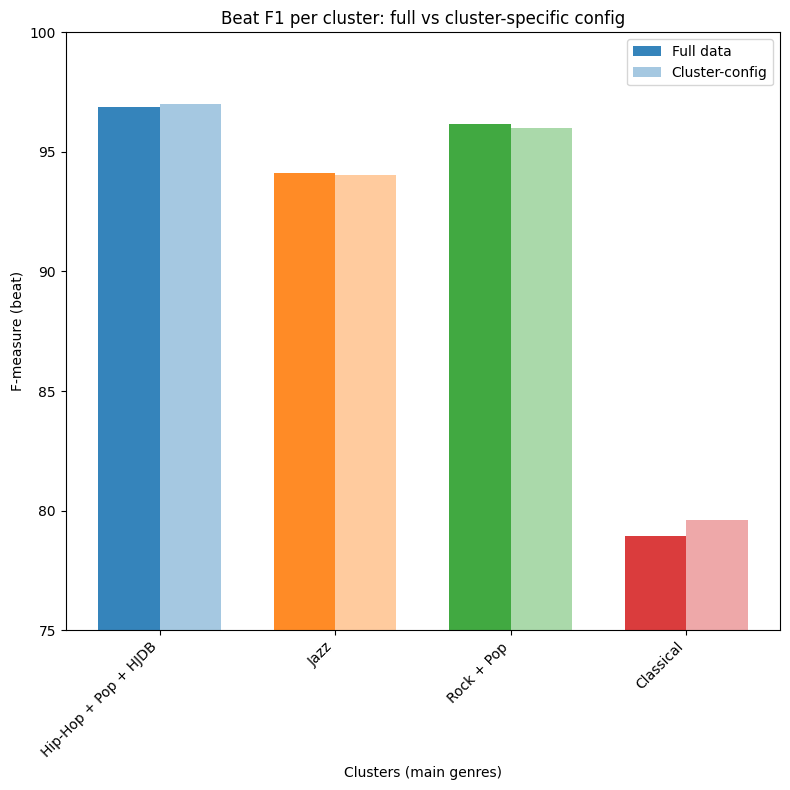

In [131]:
bar_plot_per_cluster (df_path = "data_cluster_assignments/df_cmeans_12_4clusters_new.csv", json_path =  "json_val_scores",
                       clusters = [1,2,3,4], seeds =[0,1,2] , cluster_config= "clusters4_layer12")

347
347
genres are Pop + Groove + Rock + Hip-Hop
209
209
genres are Classical + Jazz


(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Beat F1 per cluster: full vs cluster-specific config'}, xlabel='Clusters (main genres)', ylabel='F-measure (beat)'>)

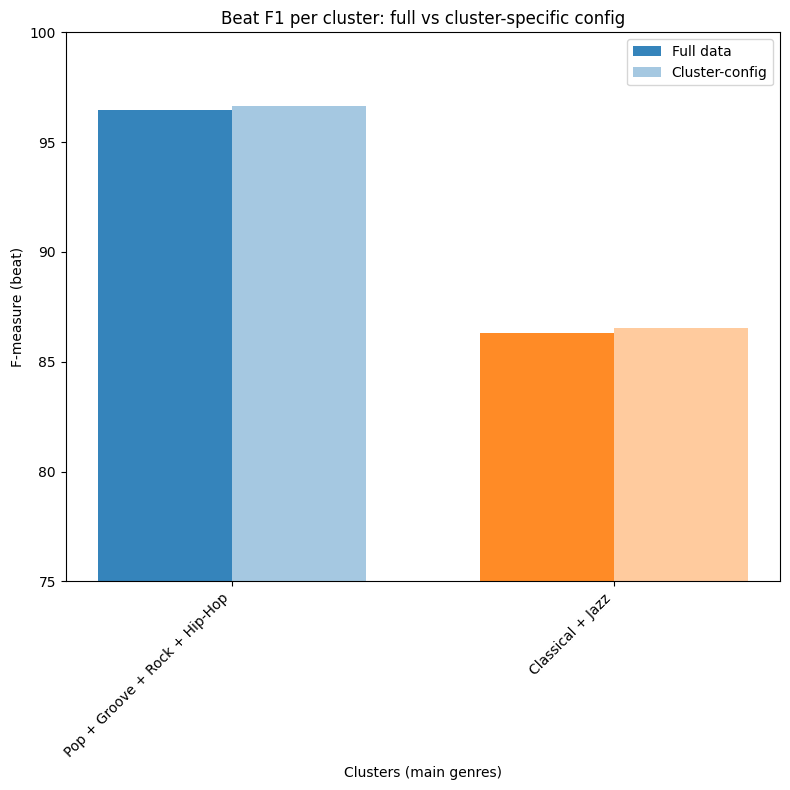

In [133]:
bar_plot_per_cluster (df_path = "data_cluster_assignments/df_hard_6_2clusters_new.csv", json_path =  "json_val_scores",
                       clusters = [1,2], seeds =[0,1,2] , cluster_config= "clusters2_layer6")

184
184
genres are Classical + Groove + Jazz
204
204
genres are Pop + Rock + HJDB + Hip-Hop
168
168
genres are Jazz + Pop + Rock


(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Beat F1 per cluster: full vs cluster-specific config'}, xlabel='Clusters (main genres)', ylabel='F-measure (beat)'>)

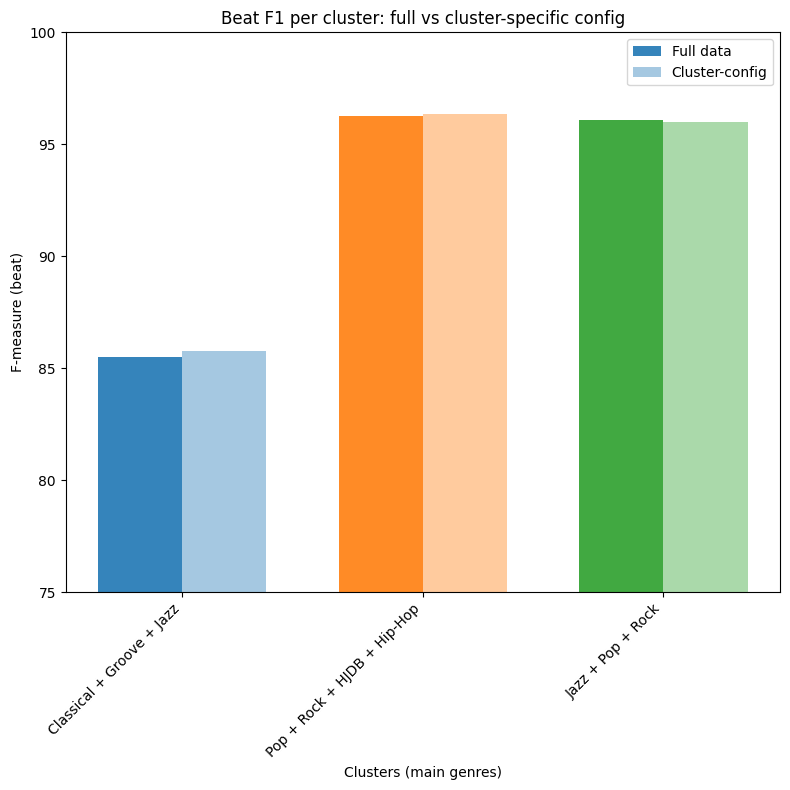

In [134]:
bar_plot_per_cluster (df_path = "data_cluster_assignments/df_raw_113_3clusters_new.csv", json_path =  "json_val_scores",
                       clusters = [1,2, 3], seeds =[0,1,2] , cluster_config= "clusters3_layer113")

In [97]:

json_path = "json_val_scores"
scores = get_restults_per_cluster (json_path,  cluster = 4, seeds = [0,1,2], df_path= "data_cluster_assignments/df_cmeans_12_4clusters_new.csv", full = True, per_cluster=True )
df = pd.DataFrame(scores)

summary = pd.DataFrame({
    "mean": df.mean(),
    "std": df.std()
})
summary.loc["F-measure_beat", "mean"]

genres are 4 (Classical)
106


78.95359938663142

In [102]:
scores = get_restults_per_cluster (json_path,  cluster = 4, seeds = [0,1,2], df_path= "data_cluster_assignments/df_cmeans_12_4clusters_new.csv", full =False,cluster_config="clusters4_layer12")
df = pd.DataFrame(scores)

summary = pd.DataFrame({
    "mean": df.mean(),
    "std": df.std()
})
summary

genres are 4 (Classical)
106


,mean,std
F-measure_beat,79.591125,0.690399
Cemgil_beat,70.760420,0.844271
CMLt_beat,62.908401,1.365148
AMLt_beat,67.816725,1.246955
F-measure_downbeat,60.752605,0.594592
Cemgil_downbeat,56.366088,0.589425
CMLt_downbeat,29.759234,0.761852
AMLt_downbeat,47.179438,0.859891


In [107]:
len(scores)

3

In [86]:
cluster_config = "clusters4_layer12"
cluster_number = 1
folder = os.path.join(json_path, cluster_config, f"{cluster_number}")
print(folder)
file_scores = [file for file in os.listdir(folder) if  file.startswith(f"best-seed{seed}")][0]   # f"best_checkpoint-seed{seed}" in file best_checkpoint-seed

json_file = open(os.path.join(folder, file_scores))
json1_str = json_file.read()
json1_data = json.loads(json1_str)
clsuter_keys = set(json1_data.keys())
print(len(clsuter_keys))
df  = pd.DataFrame(json1_data).T
df.head()

json_val_scores/clusters4_layer12/1
220


,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat
ballroom/ballroom_Albums-Cafe_Paradiso-06/track.npy,1.000000,0.892596,1.000000,1.000000,1.000000,0.877787,1.000000,1.000000
ballroom/ballroom_Albums-Cafe_Paradiso-07/track.npy,0.990291,0.933492,0.980769,0.980769,1.000000,0.959112,1.000000,1.000000
ballroom/ballroom_Albums-Fire-02/track.npy,1.000000,0.944806,1.000000,1.000000,1.000000,0.942174,1.000000,1.000000
ballroom/ballroom_Albums-Latin_Jam2-02/track.npy,1.000000,0.972828,1.000000,1.000000,0.952381,0.911810,0.909091,0.909091
ballroom/ballroom_Albums-Latin_Jam2-06/track.npy,0.990654,0.972931,0.981481,0.981481,0.962963,0.947422,0.928571,0.928571


In [ ]:
def get_total_results (seeds, json_val_path, cluster_config, cluster_numbers):
    df_list = []
    for seed in seeds:
        df_total = construct_total_df (json_val_path, seed=seed, cluster_config=cluster_config, cluster_numbers=cluster_numbers)
        df_full = construct_df_full_data (json_val_path, seed=seed, rename_columns="baseline")
        diff_dict = get_performance_differences (df_total, df_full)
        diff_dict_renamed = rename_keys_dict(diff_dict)
        #print(diff_dict_renamed)
        df = pd.DataFrame.from_dict(diff_dict_renamed, orient="index", columns=[f"Value_{seed}"])
        #df.index.name = "Metric"
        df_list.append(df)
    df_result =  pd.concat(df_list, axis=1)
    return df_result

In [ ]:
import json
import os
json_val_path = "json_val_scores/clusters4_layer12"
keys = {}
for i in range (1,5):
    folder = os.path.join(json_val_path, str(i))
    file_scores = [file for file in os.listdir(folder) if "best_checkpoint" in file][0]

    json_file = open(os.path.join(folder, file_scores))
    json1_str = json_file.read()
    json1_data = json.loads(json1_str)
    clsuter_keys = set(json1_data.keys())
    keys[i] = clsuter_keys
print(keys)

In [53]:
df1 = construct_df_clsuter_data(json_val_path, seed=0,cluster_config = "clusters2_layer6", cluster_number= 1,rename_columns= "clusters2_layer6")
df2 = construct_df_clsuter_data(json_val_path, seed=0,cluster_config = "clusters2_layer6", cluster_number= 2,rename_columns= "clusters2_layer6")
df_total = pd.concat([df1, df2], axis=0)
cols_f = [col for col in df_total.columns if "F-measure" in col]
df_total_f1 = df_total[cols_f]
df_total_f1 
means_total = (df_total.mean()* 100).to_dict()
means_total

347
209


{'F-measure_beat_clusters2_layer60': 92.87020670156396,
 'Cemgil_beat_clusters2_layer60': 85.10952250954362,
 'CMLt_beat_clusters2_layer60': 85.21058281061691,
 'AMLt_beat_clusters2_layer60': 89.36609345033831,
 'F-measure_downbeat_clusters2_layer60': 85.43487355624686,
 'Cemgil_downbeat_clusters2_layer60': 79.45757279218076,
 'CMLt_downbeat_clusters2_layer60': 72.77422067995289,
 'AMLt_downbeat_clusters2_layer60': 80.82696071845093}

In [54]:
df_full = construct_df_full_data (json_val_path, seed=0, rename_columns="baseline")
cols_f = [col for col in df_full.columns if "F-measure" in col]
df_fulll_f1 = df_full[cols_f]
means_full =(df_full.mean()*  100).to_dict()
means_full

556


{'F-measure_beat_baseline0': 92.67559037887163,
 'Cemgil_beat_baseline0': 84.89799383668344,
 'CMLt_beat_baseline0': 84.60569681054906,
 'AMLt_beat_baseline0': 88.71768403791125,
 'F-measure_downbeat_baseline0': 85.11133744115672,
 'Cemgil_downbeat_baseline0': 79.10203722776434,
 'CMLt_downbeat_baseline0': 72.10066458824532,
 'AMLt_downbeat_baseline0': 79.43592982857372}

In [55]:
diff_dict = {list(means_total.keys())[i]: means_total[list(means_total.keys())[i]] - means_full[list(means_full.keys())[i]] for i in range(len(means_full))}
diff_dict

{'F-measure_beat_clusters2_layer60': 0.1946163226923261,
 'Cemgil_beat_clusters2_layer60': 0.21152867286018306,
 'CMLt_beat_clusters2_layer60': 0.6048860000678502,
 'AMLt_beat_clusters2_layer60': 0.648409412427057,
 'F-measure_downbeat_clusters2_layer60': 0.32353611509013547,
 'Cemgil_downbeat_clusters2_layer60': 0.35553556441641376,
 'CMLt_downbeat_clusters2_layer60': 0.6735560917075674,
 'AMLt_downbeat_clusters2_layer60': 1.3910308898772143}

In [85]:
df_total = construct_total_df (json_val_path, seed=0, cluster_config="clusters2_layer6", cluster_numbers=[1,2])
df_full = construct_df_full_data (json_val_path, seed=0, rename_columns="baseline")
diff_dict = get_performance_differences (df_total, df_full)
diff_dict

347
209
Final size of df is 556
556


{'F-measure_beat_clusters2_layer6_0': 0.19461632269238294,
 'Cemgil_beat_clusters2_layer6_0': 0.211528672860112,
 'CMLt_beat_clusters2_layer6_0': 0.6048860000678076,
 'AMLt_beat_clusters2_layer6_0': 0.6484094124270428,
 'F-measure_downbeat_clusters2_layer6_0': 0.3235361150901497,
 'Cemgil_downbeat_clusters2_layer6_0': 0.35553556441637113,
 'CMLt_downbeat_clusters2_layer6_0': 0.6735560917075816,
 'AMLt_downbeat_clusters2_layer6_0': 1.3910308898772996}

In [17]:
df_total = construct_total_df (json_val_path, seed=0, cluster_config="clusters4_layer12", cluster_numbers=[1,2, 3,4])
df_full = construct_df_full_data (json_val_path, seed=0, rename_columns="baseline")
diff_dict0 = get_performance_differences (df_total, df_full)
diff_dict0

json_val_scores/clusters4_layer12/1
220
json_val_scores/clusters4_layer12/2
123
json_val_scores/clusters4_layer12/3
153
json_val_scores/clusters4_layer12/4
106
Final size of df is 556
556


{'F-measure_beat_clusters4_layer12_0': 0.17011146854920867,
 'Cemgil_beat_clusters4_layer12_0': 0.21154820779605643,
 'CMLt_beat_clusters4_layer12_0': 0.6858410904917349,
 'AMLt_beat_clusters4_layer12_0': 0.5422025666788244,
 'F-measure_downbeat_clusters4_layer12_0': 0.2828661715811478,
 'Cemgil_downbeat_clusters4_layer12_0': 0.23577475631742573,
 'CMLt_downbeat_clusters4_layer12_0': 0.681876299303525,
 'AMLt_downbeat_clusters4_layer12_0': 0.9236112107499537}

In [7]:
#df0 = pd.DataFrame.from_dict(diff_dict0, orient='index', columns = ["Values0"])
df1= pd.DataFrame.from_dict(list(diff_dict1.items()), columns = ["Metric", "Value"] )
# df_res =  pd.concat([df0, df1], axis=0)
# df_res
df1

ValueError: cannot use columns parameter with orient='columns'

In [13]:
df1 = pd.DataFrame(list(diff_dict1.items()), columns=["Metric", "Value"])
df1

,Metric,Value
0,F-measure_beat_clusters4_layer12_1,-0.045774
1,Cemgil_beat_clusters4_layer12_1,-0.146955
2,CMLt_beat_clusters4_layer12_1,-0.323932
3,AMLt_beat_clusters4_layer12_1,-0.020322
4,F-measure_downbeat_clusters4_layer12_1,0.009791
5,Cemgil_downbeat_clusters4_layer12_1,-0.137542
6,CMLt_downbeat_clusters4_layer12_1,-0.178244
7,AMLt_downbeat_clusters4_layer12_1,-0.558642


In [14]:
diff_dict1.items()

dict_items([('F-measure_beat_clusters4_layer12_1', -0.04577390748724497), ('Cemgil_beat_clusters4_layer12_1', -0.1469553476583485), ('CMLt_beat_clusters4_layer12_1', -0.32393166924647687), ('AMLt_beat_clusters4_layer12_1', -0.020321947870471035), ('F-measure_downbeat_clusters4_layer12_1', 0.009791016016123422), ('Cemgil_downbeat_clusters4_layer12_1', -0.13754175909721766), ('CMLt_downbeat_clusters4_layer12_1', -0.17824391657016747), ('AMLt_downbeat_clusters4_layer12_1', -0.55864231428464)])

In [23]:
dict1_new = {}
for key in diff_dict1.keys():
    new_key = "_".join(key.split("_")[:-1])
    dict1_new [new_key] = diff_dict1[key]
dict1_new

{'F-measure_beat_clusters4_layer12': -0.04577390748724497,
 'Cemgil_beat_clusters4_layer12': -0.1469553476583485,
 'CMLt_beat_clusters4_layer12': -0.32393166924647687,
 'AMLt_beat_clusters4_layer12': -0.020321947870471035,
 'F-measure_downbeat_clusters4_layer12': 0.009791016016123422,
 'Cemgil_downbeat_clusters4_layer12': -0.13754175909721766,
 'CMLt_downbeat_clusters4_layer12': -0.17824391657016747,
 'AMLt_downbeat_clusters4_layer12': -0.55864231428464}

In [20]:
import os
import json
json_val_path = "json_val_scores"
df_total = construct_total_df (json_val_path, seed=1, cluster_config="clusters4_layer12", cluster_numbers=[1,2, 3,4])
df_full = construct_df_full_data (json_val_path, seed=1, rename_columns="baseline")
diff_dict1 = get_performance_differences (df_total, df_full)
diff_dict1

json_val_scores/clusters4_layer12/1
220
json_val_scores/clusters4_layer12/2
123
json_val_scores/clusters4_layer12/3
153
json_val_scores/clusters4_layer12/4
106
Final size of df is 556
556


{'F-measure_beat_clusters4_layer12_1': -0.04577390748724497,
 'Cemgil_beat_clusters4_layer12_1': -0.1469553476583485,
 'CMLt_beat_clusters4_layer12_1': -0.32393166924647687,
 'AMLt_beat_clusters4_layer12_1': -0.020321947870471035,
 'F-measure_downbeat_clusters4_layer12_1': 0.009791016016123422,
 'Cemgil_downbeat_clusters4_layer12_1': -0.13754175909721766,
 'CMLt_downbeat_clusters4_layer12_1': -0.17824391657016747,
 'AMLt_downbeat_clusters4_layer12_1': -0.55864231428464}

In [42]:
def rename_keys_dict(d):
    dict_new = {}
    for key in d.keys():
        new_key = "_".join(key.split("_")[:-1])
        dict_new [new_key] = d[key]
    return dict_new
def get_total_results (seeds, json_val_path, cluster_config, cluster_numbers):
    df_list = []
    for seed in seeds:
        df_total = construct_total_df (json_val_path, seed=seed, cluster_config=cluster_config, cluster_numbers=cluster_numbers)
        df_full = construct_df_full_data (json_val_path, seed=seed, rename_columns="baseline")
        diff_dict = get_performance_differences (df_total, df_full)
        diff_dict_renamed = rename_keys_dict(diff_dict)
        #print(diff_dict_renamed)
        df = pd.DataFrame.from_dict(diff_dict_renamed, orient="index", columns=[f"Value_{seed}"])
        #df.index.name = "Metric"
        df_list.append(df)
    df_result =  pd.concat(df_list, axis=1)
    return df_result

In [45]:
df_total = get_total_results (seeds = [0,1], json_val_path = "json_val_scores", cluster_config="clusters4_layer12", cluster_numbers=[1,2, 3,4])
df_total.mean(axis = 1)
df_total

json_val_scores/clusters4_layer12/1
220
json_val_scores/clusters4_layer12/2
123
json_val_scores/clusters4_layer12/3
153
json_val_scores/clusters4_layer12/4
106
Final size of df is 556
556
json_val_scores/clusters4_layer12/1
220
json_val_scores/clusters4_layer12/2
123
json_val_scores/clusters4_layer12/3
153
json_val_scores/clusters4_layer12/4
106
Final size of df is 556
556


,Value_0,Value_1
F-measure_beat_clusters4_layer12,0.170111,-0.045774
Cemgil_beat_clusters4_layer12,0.211548,-0.146955
CMLt_beat_clusters4_layer12,0.685841,-0.323932
AMLt_beat_clusters4_layer12,0.542203,-0.020322
F-measure_downbeat_clusters4_layer12,0.282866,0.009791
Cemgil_downbeat_clusters4_layer12,0.235775,-0.137542
CMLt_downbeat_clusters4_layer12,0.681876,-0.178244
AMLt_downbeat_clusters4_layer12,0.923611,-0.558642


In [ ]:
import os
import json
json_val_path = "json_val_scores"
df_total = construct_total_df (json_val_path, seed=0, cluster_config="clusters3_layer113", cluster_numbers=[1,2, 3])
df_full = construct_df_full_data (json_val_path, seed=0, rename_columns="baseline")
diff_dict = get_performance_differences (df_total, df_full)
diff_dict

json_val_scores/clusters3_layer113/1
184
json_val_scores/clusters3_layer113/2
204
json_val_scores/clusters3_layer113/3
168
Final size of df is 556
556


{'F-measure_beat_clusters3_layer113_0': -0.009816996519390386,
 'Cemgil_beat_clusters3_layer113_0': -0.23713233829714397,
 'CMLt_beat_clusters3_layer113_0': 0.19418560072544722,
 'AMLt_beat_clusters3_layer113_0': 0.03538814802558932,
 'F-measure_downbeat_clusters3_layer113_0': 0.20640883754387573,
 'Cemgil_downbeat_clusters3_layer113_0': -0.14219493196397082,
 'CMLt_downbeat_clusters3_layer113_0': 0.4797200504718404,
 'AMLt_downbeat_clusters3_layer113_0': 0.33998351550118855}

In [ ]:
df_total.isna() 

,F-measure_beat_clusters3_layer113_0,Cemgil_beat_clusters3_layer113_0,CMLt_beat_clusters3_layer113_0,AMLt_beat_clusters3_layer113_0,F-measure_downbeat_clusters3_layer113_0,Cemgil_downbeat_clusters3_layer113_0,CMLt_downbeat_clusters3_layer113_0,AMLt_downbeat_clusters3_layer113_0
asap/Bach_Fugue_bwv_873_Lisiecki13M/track.npy,False,False,False,False,False,False,False,False
asap/Bach_Fugue_bwv_874_BianF01/track.npy,False,False,False,False,False,False,False,False
asap/Bach_Fugue_bwv_874_Kurz01M/track.npy,False,False,False,False,False,False,False,False
asap/Bach_Fugue_bwv_874_WongWY01M/track.npy,False,False,False,False,False,False,False,False
asap/Bach_Fugue_bwv_875_Ahfat01M/track.npy,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
tapcorrect/066_youtube_H4BB9eGUEaE/track.npy,False,False,False,False,False,False,False,False
tapcorrect/069_youtube_8kl6q_9qZOs/track.npy,False,False,False,False,False,False,False,False
tapcorrect/087_youtube_ej93qIAlhXs/track.npy,False,False,False,False,False,False,False,False
tapcorrect/093_youtube_C1lbOgBtE3w/track.npy,False,False,False,False,False,False,False,False


In [70]:
df2

,F-measure_beat_clusters4_layer120,Cemgil_beat_clusters4_layer120,CMLt_beat_clusters4_layer120,AMLt_beat_clusters4_layer120,F-measure_downbeat_clusters4_layer120,Cemgil_downbeat_clusters4_layer120,CMLt_downbeat_clusters4_layer120,AMLt_downbeat_clusters4_layer120
ballroom/ballroom_Albums-Cafe_Paradiso-01/track.npy,1.000000,0.922979,1.000000,1.000000,1.000000,0.896015,1.000000,1.000000
ballroom/ballroom_Albums-Cafe_Paradiso-07/track.npy,1.000000,0.974899,1.000000,1.000000,1.000000,0.995267,1.000000,1.000000
ballroom/ballroom_Albums-Cafe_Paradiso-12/track.npy,1.000000,0.954732,1.000000,1.000000,0.952381,0.898297,0.909091,0.909091
ballroom/ballroom_Albums-Commitments-08/track.npy,0.971014,0.947054,0.929577,0.929577,0.969697,0.937109,0.941176,0.941176
ballroom/ballroom_Albums-Commitments-11/track.npy,1.000000,0.936685,1.000000,1.000000,1.000000,0.952677,1.000000,1.000000
...,...,...,...,...,...,...,...,...
tapcorrect/045_youtube_SYUgGs9IStY/track.npy,0.781570,0.776370,0.280112,0.562363,0.642857,0.704612,0.052632,0.684211
tapcorrect/066_youtube_H4BB9eGUEaE/track.npy,1.000000,0.951452,1.000000,1.000000,0.862500,0.831361,0.627907,0.627907
tapcorrect/069_youtube_8kl6q_9qZOs/track.npy,0.963438,0.876585,0.930521,0.930521,0.949495,0.847326,0.908213,0.908213
tapcorrect/087_youtube_ej93qIAlhXs/track.npy,0.996870,0.965523,0.993760,0.993760,0.996865,0.958880,0.993750,0.993750


In [73]:
len(set(df1.index)  & set(df2.index))

28

In [67]:
idncies_repeat = [ind for ind in df_total.index.to_list() if df_total.index.to_list().count(ind) >1]
len(idncies_repeat)

56

In [11]:
mapping

{'F-measure_beat_full_data_seed0': 'F-measure_beat',
 'Cemgil_beat_full_data_seed0': 'Cemgil_beat',
 'CMLt_beat_full_data_seed0': 'CMLt_beat',
 'AMLt_beat_full_data_seed0': 'AMLt_beat',
 'F-measure_downbeat_full_data_seed0': 'F-measure_downbeat',
 'Cemgil_downbeat_full_data_seed0': 'Cemgil_downbeat',
 'CMLt_downbeat_full_data_seed0': 'CMLt_downbeat',
 'AMLt_downbeat_full_data_seed0': 'AMLt_downbeat'}

In [12]:
seed = 0
mapping = { col: f"{col}_full_data_seed{seed}" for col in df.columns}
df = df.rename(columns=mapping)
df

,F-measure_beat_full_data_seed0,Cemgil_beat_full_data_seed0,CMLt_beat_full_data_seed0,AMLt_beat_full_data_seed0,F-measure_downbeat_full_data_seed0,Cemgil_downbeat_full_data_seed0,CMLt_downbeat_full_data_seed0,AMLt_downbeat_full_data_seed0
asap/Bach_Fugue_bwv_873_Lisiecki13M/track.npy,0.990689,0.946179,0.977695,0.977695,0.554545,0.619217,0.045752,0.437908
asap/Bach_Fugue_bwv_874_BianF01/track.npy,0.103806,0.089323,0.000000,0.606218,0.040201,0.036285,0.000000,0.000000
asap/Bach_Fugue_bwv_874_Kurz01M/track.npy,0.666667,0.768584,0.000000,0.984536,0.571429,0.662933,0.000000,0.600000
asap/Bach_Fugue_bwv_874_WongWY01M/track.npy,0.664384,0.763135,0.000000,0.969231,0.548780,0.627003,0.000000,0.586207
asap/Bach_Fugue_bwv_875_Ahfat01M/track.npy,0.736842,0.717897,0.361111,0.385366,0.355932,0.387693,0.000000,0.173913
...,...,...,...,...,...,...,...,...
tapcorrect/066_youtube_H4BB9eGUEaE/track.npy,1.000000,0.952138,1.000000,1.000000,0.867925,0.831172,0.647059,0.647059
tapcorrect/069_youtube_8kl6q_9qZOs/track.npy,0.960358,0.864980,0.924784,0.924784,0.930693,0.827054,0.874419,0.874419
tapcorrect/087_youtube_ej93qIAlhXs/track.npy,0.996870,0.969499,0.993760,0.993760,0.996865,0.965355,0.993750,0.993750
tapcorrect/093_youtube_C1lbOgBtE3w/track.npy,0.909890,0.838151,0.690909,0.690909,0.803089,0.766750,0.348387,0.478261


In [7]:
import json
import os
import pandas as pd
json_val_path = "json_val_scores"
keys = {}

folder = os.path.join(json_val_path, "full_data")
file_scores = [file for file in os.listdir(folder) if "best-seed0" in file][0]

json_file = open(os.path.join(folder, file_scores))
json1_str = json_file.read()
json1_data = json.loads(json1_str)
clsuter_keys = set(json1_data.keys())
print(len(clsuter_keys))
df  = pd.DataFrame(json1_data).T
df

556


,F-measure_beat,Cemgil_beat,CMLt_beat,AMLt_beat,F-measure_downbeat,Cemgil_downbeat,CMLt_downbeat,AMLt_downbeat
asap/Bach_Fugue_bwv_873_Lisiecki13M/track.npy,0.990689,0.946179,0.977695,0.977695,0.554545,0.619217,0.045752,0.437908
asap/Bach_Fugue_bwv_874_BianF01/track.npy,0.103806,0.089323,0.000000,0.606218,0.040201,0.036285,0.000000,0.000000
asap/Bach_Fugue_bwv_874_Kurz01M/track.npy,0.666667,0.768584,0.000000,0.984536,0.571429,0.662933,0.000000,0.600000
asap/Bach_Fugue_bwv_874_WongWY01M/track.npy,0.664384,0.763135,0.000000,0.969231,0.548780,0.627003,0.000000,0.586207
asap/Bach_Fugue_bwv_875_Ahfat01M/track.npy,0.736842,0.717897,0.361111,0.385366,0.355932,0.387693,0.000000,0.173913
...,...,...,...,...,...,...,...,...
tapcorrect/066_youtube_H4BB9eGUEaE/track.npy,1.000000,0.952138,1.000000,1.000000,0.867925,0.831172,0.647059,0.647059
tapcorrect/069_youtube_8kl6q_9qZOs/track.npy,0.960358,0.864980,0.924784,0.924784,0.930693,0.827054,0.874419,0.874419
tapcorrect/087_youtube_ej93qIAlhXs/track.npy,0.996870,0.969499,0.993760,0.993760,0.996865,0.965355,0.993750,0.993750
tapcorrect/093_youtube_C1lbOgBtE3w/track.npy,0.909890,0.838151,0.690909,0.690909,0.803089,0.766750,0.348387,0.478261


In [6]:
json1_data

{'asap/Bach_Fugue_bwv_873_Lisiecki13M/track.npy': {'F-measure_beat': 0.9906890130353817,
  'Cemgil_beat': 0.9461791100978764,
  'CMLt_beat': 0.9776951672862454,
  'AMLt_beat': 0.9776951672862454,
  'F-measure_downbeat': 0.5545454545454546,
  'Cemgil_downbeat': 0.6192171586932619,
  'CMLt_downbeat': 0.0457516339869281,
  'AMLt_downbeat': 0.43790849673202614},
 'asap/Bach_Fugue_bwv_874_BianF01/track.npy': {'F-measure_beat': 0.10380622837370242,
  'Cemgil_beat': 0.08932329235123523,
  'CMLt_beat': 0.0,
  'AMLt_beat': 0.6062176165803109,
  'F-measure_downbeat': 0.04020100502512563,
  'Cemgil_downbeat': 0.03628480207402904,
  'CMLt_downbeat': 0.0,
  'AMLt_downbeat': 0.0},
 'asap/Bach_Fugue_bwv_874_Kurz01M/track.npy': {'F-measure_beat': 0.6666666666666666,
  'Cemgil_beat': 0.7685835752035493,
  'CMLt_beat': 0.0,
  'AMLt_beat': 0.9845360824742269,
  'F-measure_downbeat': 0.5714285714285715,
  'Cemgil_downbeat': 0.6629334122797284,
  'CMLt_downbeat': 0.0,
  'AMLt_downbeat': 0.6},
 'asap/Bach_F